In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from toolbox_mingyang import show_mri, fft2c_mingyang, ifft2c_mingyang


f = h5py.File("../data/SimuData.mat", "r")
print(list(f.keys()))

['Image', 'Magnitude', 'Phase']


我的工程目录结构是这样的:
MRI_LIB/
│
├─ data/
|   ├─ LiverData.mat
│   └─ SimuData.mat
│
├─ notebooks/
│   ├─ 01_kspace_fft.ipynb
│   ├─ XXXXXX.ipynb
│   └─ 10_summary_experiments.ipynb
│
└─ toolbox_mingyang.py

读取mat数据需要其准确的路径。导入自己写的函数则需要用sys把上一级目录加入Python模块搜索路径当中。SimuData.mat当中保存了三个数据，第一个是常用的复数图像数据Image，另外两个是组成Image用的幅值Magnitude和相位Phase。

In [2]:
Image = f["Image"][:]
print(Image.shape)
print(type(Image))
print(Image.dtype)

(4, 256, 256)
<class 'numpy.ndarray'>
[('real', '<f8'), ('imag', '<f8')]


这里面取出来mat文件中的Image数据。shape可以看出来是4 256 256，这个和matlab保存的数据维度是正好反的，在matlab当中保存的时候RO=256 PE=256 Nshot=4，也是这个顺序，现在读取出来与之相反。剩下两句只是为了看一下Image的一些基本属性

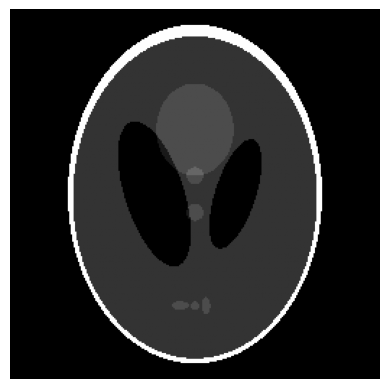

In [3]:
img = Image['real'] + 1j * Image['imag']
show_mri(img[1], "mag")

这个步骤是因为要把数据重新写成复数，因为python读取mat文件的时候直接把complex double类型给拆成了实部和虚部，所以要先变回去。

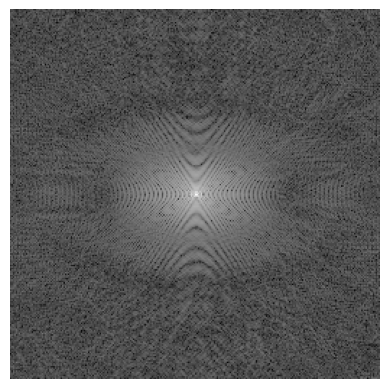

In [4]:
kspace = fft2c_mingyang(img)
show_mri(kspace[1], "kspace")

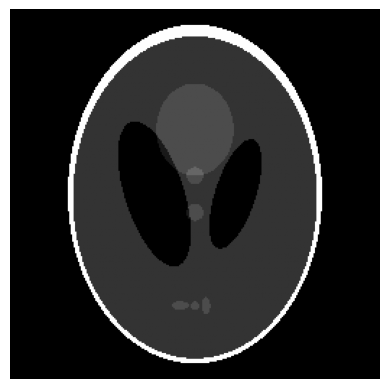

In [5]:
recon = ifft2c_mingyang(kspace)
recon_img = np.abs(recon)

show_mri(recon_img[1], "mag")

In [6]:
error = np.linalg.norm(img[1] - recon_img[1])
print("Reconstruction error:", error)

Reconstruction error: 94.85661289225777
